In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from IPython.display import display
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer


#### Prepared by **Anastasiia Sviridova** (Student ID 466520)

# **1. Introduction**

## **Purpose of the Project**
The primary objective of this project is to conduct **sentiment analysis** on customer reviews from the **Sephora products dataset**. The goal is to classify whether a review reflects a **positive or negative sentiment**, using the `is_recommended` column as the **target variable**.

Additionally, this project aims to explore **trends and patterns** in reviews, offering deeper insights into **customer preferences** and **feedback**.

## **Main Assumptions**
Before conducting the analysis, we define the following **assumptions**:

- **Negative reviews tend to be longer** on average compared to positive reviews.
- **More expensive brands** are associated with a **higher proportion of positive reviews**.

## **Research Areas**
This project investigates the following key **research areas**:

- Identifying **trends** in **positive and negative reviews** over time.
- Determining which **brands and products** receive more **positive or negative** reviews.
- Analyzing the relationship between **review length and sentiment**.
- Examining whether **brand pricing** influences customer satisfaction.
- Exploring Key Themes in Customer Reviews Using **LDA Topic Modeling**

# **2. Data**

## **Dataset Description**
The dataset used in this project originates from **Kaggle** and contains **customer reviews** of beauty and skincare products from **Sephora**. It includes key attributes such as **brand names, product names, review text, sentiment labels, pricing information, and timestamps** of reviews.

📌 **Source:** [Sephora Products and Skincare Reviews on Kaggle](https://www.kaggle.com/datasets/nadyinky/sephora-products-and-skincare-reviews?select=product_info.csv)

---

The raw dataset consists of **483,645** reviews and the following **columns**:

- **`author_id`** – Unique identifier for the reviewer.
- **`rating`** – Star rating given by the reviewer (e.g., 1–5 stars).
- **`is_recommended`** – Binary sentiment label (1 = recommended, 0 = not recommended).
- **`helpfulness`** – Indicates whether the review was marked as helpful.
- **`total_feedback_count`** – Total number of feedback interactions on the review.
- **`total_neg_feedback_count`** – Number of negative reactions to the review.
- **`total_pos_feedback_count`** – Number of positive reactions to the review.
- **`submission_time`** – The timestamp when the review was posted.
- **`review_text`** – The full text of the customer review.
- **`review_title`** – Title of the review (if available).
- **`skin_tone`** – The reviewer's skin tone (if provided).
- **`eye_color`** – The reviewer's eye color (if provided).
- **`skin_type`** – The reviewer's skin type (if provided).
- **`hair_color`** – The reviewer's hair color (if provided).
- **`product_id`** – Unique identifier for the product being reviewed.
- **`product_name`** – Name of the product reviewed.
- **`brand_name`** – The brand of the product.
- **`price_usd`** – The price of the product in USD.


# **3. Preparation of Data**  

## **Data Cleaning & Preprocessing**
The **data cleaning and preprocessing** steps were implemented in the **Python script**:  
📌 [`src/data_cleaning.py`](../src/data_cleaning.py)

After executing this script, we obtained the **cleaned dataset**:  
📌 `data/cleaned_reviews.csv`

---

## **Preprocessing Steps**
To ensure **data consistency** and improve the **accuracy of sentiment analysis models**, the following **cleaning and transformation steps** were applied:

1️⃣ **Handling Missing Values**  
   - Removed rows where essential fields were missing:  
     - `review_text`, `is_recommended`, `brand_name`, `price_usd`, `submission_time`, and `product_name`.

2️⃣ **Processing Dates**  
   - Converted `submission_time` into **datetime format**.
   - Extracted **year** and **month** into separate columns for future trend analysis.

3️⃣ **Review Text Cleaning**  
   - **Converted text to lowercase.**  
   - **Removed special characters and numbers.**  
   - **Tokenized and lemmatized words** using **spaCy's `en_core_web_sm` model**.  
   - **Removed stopwords** to keep only meaningful words.

4️⃣ **Product Name Cleaning**  
   - Removed special characters from **product names** and converted them to lowercase.

5️⃣ **Feature Engineering**  
   - Created a **`review_length`** column to store the length of each review (in characters).

6️⃣ **Saving the Processed Data**  
   - The final **cleaned dataset** was saved as:  
     📌 `data/cleaned_reviews.csv`

# **4. Loading Data and Feature Engineering** 

In [8]:
# Change the working directory 
os.chdir("C:/Users/User/Documents/3 semester/text mining/project/sentiment_analysis_project")

# Verify the new working directory
print("New Working Directory:", os.getcwd())

# Loading the cleaning data
cleaned_data_path = "data/cleaned_reviews.csv"
df = pd.read_csv(cleaned_data_path)

# Setting the style of graphs
sns.set(style="whitegrid")

New Working Directory: C:\Users\User\Documents\3 semester\text mining\project\sentiment_analysis_project


C:\Users\User\AppData\Local\Temp\ipykernel_22776\2413946259.py:9: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(cleaned_data_path)


In [9]:
# Converting is_recommended
df['is_recommended'] = df['is_recommended'].astype(int)

# Converting price_usd
df['price_usd'] = df['price_usd'].astype(int)

# Converting month on the text format
month_names = {
    1: 'January', 2: 'February', 3: 'March', 4: 'April', 5: 'May', 6: 'June',
    7: 'July', 8: 'August', 9: 'September', 10: 'October', 11: 'November', 12: 'December'
}
df['month'] = df['month'].map(month_names)

# Creating the database with the appropriate columns
columns_to_keep = ['brand_name', 'price_usd', 'year', 'month', 'review_length', 'cleaned_review_text', 'cleaned_product_name', 'is_recommended']
df = df[columns_to_keep]

# Cleaning database
sns.set(style="whitegrid")
plt.figure(figsize=(10, 6))
display(df.head(20)) 


,brand_name,price_usd,year,month,review_length,cleaned_review_text,cleaned_product_name,is_recommended
0,NUDESTIX,19,2023,February,455,use nudestix citrus clean balm makeup melt dou...,gentle hydragel face cleanser,1
1,LANEIGE,24,2023,March,162,buy lip mask read review hype unfortunately me...,lip sleeping mask intense hydration with vitam...,0
2,LANEIGE,24,2023,March,272,review title say excited bed apply lip mask di...,lip sleeping mask intense hydration with vitam...,1
3,LANEIGE,24,2023,March,230,ve love formula long time honestly not use nig...,lip sleeping mask intense hydration with vitam...,1
4,LANEIGE,24,2023,March,213,dry crack lip week use learn bedside think lit...,lip sleeping mask intense hydration with vitam...,1
5,LANEIGE,24,2023,March,185,scent not favourite work great night sleep mor...,lip sleeping mask intense hydration with vitam...,1
6,LANEIGE,24,2023,March,360,ill star nice packaging lovely scent initial a...,lip sleeping mask intense hydration with vitam...,0
7,LANEIGE,24,2023,March,127,use night m put makeup love way not reapply ni...,lip sleeping mask intense hydration with vitam...,1
8,LANEIGE,24,2023,March,282,love stuff sample size sephora birthday gift r...,lip sleeping mask intense hydration with vitam...,1
9,LANEIGE,24,2023,March,181,purchase sweet candy scent local sephora obses...,lip sleeping mask intense hydration with vitam...,1


<Figure size 1000x600 with 0 Axes>

**Checking NA in the cleaned dataset**

In [10]:
# Check for missing values in the filtered dataset
missing_values = df.isnull().sum()

# Display the columns with missing values
print("Missing values in the dataset:")
print(missing_values)

Missing values in the dataset:
brand_name              0
price_usd               0
year                    0
month                   0
review_length           0
cleaned_review_text     6
cleaned_product_name    0
is_recommended          0
dtype: int64


After performing **text preprocessing**, we observed that **six reviews (`cleaned_review_text`) became empty**. This happened due to the following reasons:

1️⃣ **Stopword Removal** – Some reviews may have contained only **common stopwords** (*"the," "is," "and," "I"*) which were removed, leaving an **empty string**.

2️⃣ **Special Character Removal** – If a review contained **only numbers, punctuation, or special characters**, it was cleaned out completely.

3️⃣ **Tokenization & Lemmatization** – Some reviews may have had **very few words** that were lemmatized into another form or removed due to **non-alphabetic filtering**.

To avoid errors in future analysis and modeling, we **removed these empty reviews** from the dataset.

In [11]:
# Remove rows with missing values in the 'cleaned_review_text' column
df = df.dropna(subset=['cleaned_review_text'])

# Display the shape of the updated dataset
print("Updated dataset shape:", df.shape)
missing_values = df.isnull().sum()
print("Missing values in the cleaned dataset:")
print(missing_values)


Updated dataset shape: (483639, 8)
Missing values in the cleaned dataset:
brand_name              0
price_usd               0
year                    0
month                   0
review_length           0
cleaned_review_text     0
cleaned_product_name    0
is_recommended          0
dtype: int64


# **5. Research Questions** 
## Determining which **brands and products** receive more **positive or negative** reviews.

**Top Brands by Sentiment Distribution**

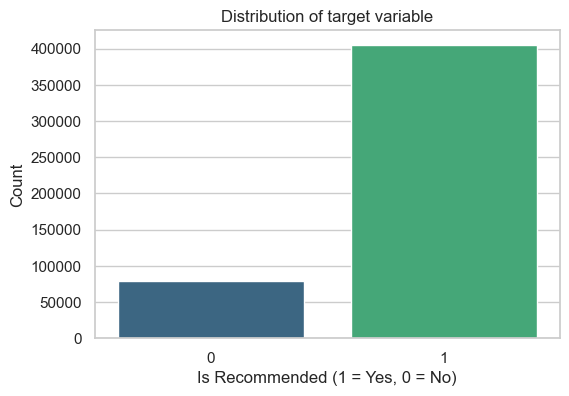

Percentage of recommendations:
is_recommended
1    83.787701
0    16.212299
Name: proportion, dtype: float64


In [56]:
# Distribution of target variable
plt.figure(figsize=(6, 4))
sns.countplot(x='is_recommended', data=df, palette='viridis', hue='is_recommended', dodge=False, legend=False)
plt.title('Distribution of target variable')
plt.xlabel('Is Recommended (1 = Yes, 0 = No)')
plt.ylabel('Count')
plt.show()

recommended_counts = df['is_recommended'].value_counts(normalize=True) * 100
print("Percentage of recommendations:")
print(recommended_counts)


We explored the distribution of target variable:

1. The data is unbalanced.

2. 83% of Sephora customers recommended the products ans 16% don't recommended.

Brand Sentiment Counts:
is_recommended                0      1
brand_name                            
Algenist                    441   3145
Biossance                   612   2887
Bobbi Brown                 192   2852
CLINIQUE                   2041  13490
Caudalie                    982   5133
Charlotte Tilbury           410   3061
Clarins                     313   2017
Dermalogica                 660  10996
Dior                        180   1249
Dr. Brandt Skincare          80   1106
Dr. Dennis Gross Skincare   542   7336
Dr. Jart+                  2496   7922
Drunk Elephant             7226  22572
Estée Lauder               2327  12270
Evian                        26    184
Farmacy                    2371  14150
First Aid Beauty           1067   5522
GUERLAIN                    290   2180
Glow Recipe                3667  17964
Herbivore                   314   1180
IT Cosmetics                513   3393
Isle of Paradise            663   2186
Jack Black                   76    778
J

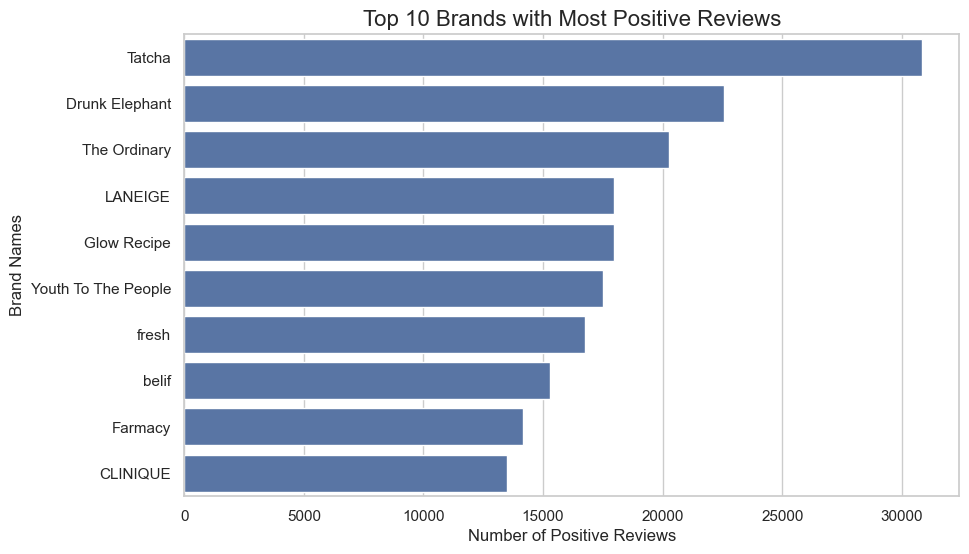

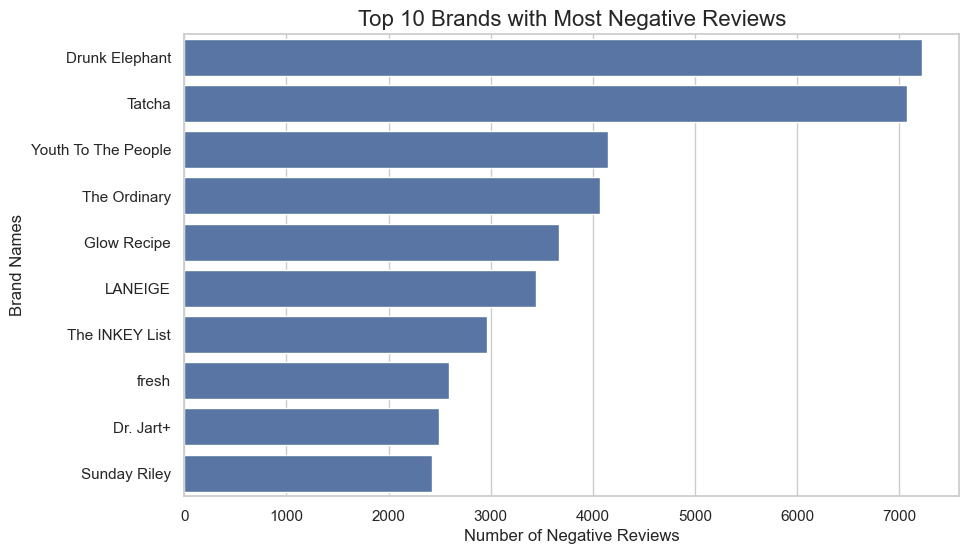

In [46]:
# Grouping data to count positive and negative reviews for each brand
brand_sentiment_counts = df.groupby(['brand_name', 'is_recommended']).size().unstack(fill_value=0)

# Display the table of brand sentiment counts
print("Brand Sentiment Counts:")
print(brand_sentiment_counts)

# Displaying the number of unique brands
print(f"\nTotal number of unique brands: {len(brand_sentiment_counts)}")

# Get top-10 brands with the most positive reviews
top_positive_brands = brand_sentiment_counts[1].sort_values(ascending=False).head(10)

# Get top-10 brands with the most negative reviews
top_negative_brands = brand_sentiment_counts[0].sort_values(ascending=False).head(10)

# Plotting top-10 brands with positive reviews
plt.figure(figsize=(10, 6))
sns.barplot(
    x=top_positive_brands.values,
    y=top_positive_brands.index
)
plt.title("Top 10 Brands with Most Positive Reviews", fontsize=16)
plt.xlabel("Number of Positive Reviews", fontsize=12)
plt.ylabel("Brand Names", fontsize=12)
plt.show()

# Plotting top-10 brands with negative reviews
plt.figure(figsize=(10, 6))
sns.barplot(
    x=top_negative_brands.values,
    y=top_negative_brands.index
)
plt.title("Top 10 Brands with Most Negative Reviews", fontsize=16)
plt.xlabel("Number of Negative Reviews", fontsize=12)
plt.ylabel("Brand Names", fontsize=12)
plt.show()


From our sentiment analysis, we identified which **brands** receive the most **positive** and **negative** reviews. 

- **Top brands with the highest number of positive reviews** include:
  - **Tatcha**
  - **Drunk Elephant**
  - **The Ordinary**
  - **LANEIGE**
  - **Glow Recipe**

These brands are popular among users, indicating high customer satisfaction and preference.

- **Top brands with the highest number of negative reviews** include:
  - **Drunk Elephant**
  - **Tatcha**
  - **Youth To The People**
  - **The Ordinary**
  - **Glow Recipe**

Interestingly, many brands appear on both lists, suggesting that while they have a strong customer base, they also receive substantial criticism. This could be due to varying experiences among different customer groups or specific product-related issues.


**Product-Level Sentiment and Pricing Analysis**

In [52]:
# Count unique products
unique_products_count = df['cleaned_product_name'].nunique()
print(f"Total number of unique products: {unique_products_count}")

# Create a table with unique product names and their sentiment counts
product_sentiment_counts = df.groupby(['cleaned_product_name', 'is_recommended']).size().unstack(fill_value=0)

display(product_sentiment_counts)

Total number of unique products: 249


is_recommended,0,1
cleaned_product_name,,
organic coldpressed rose hip seed oil,212,1407
percent pure argan oil,138,848
stars retinol niacinamide eye serum,99,1622
abeille royale advanced youth watery oil,145,1090
acne control clarifying cleanser,150,631
...,...,...
watermelon glow pha bha poretight toner,476,2845
watermelon pink juice oilfree moisturizer,507,1419
whipped argan oil face butter,181,810


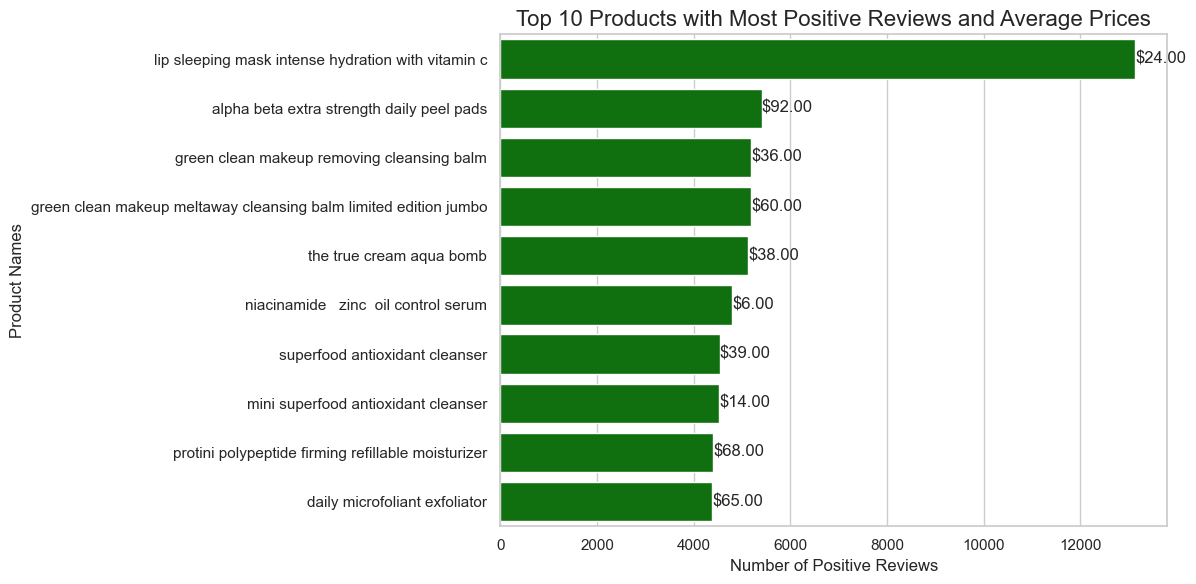

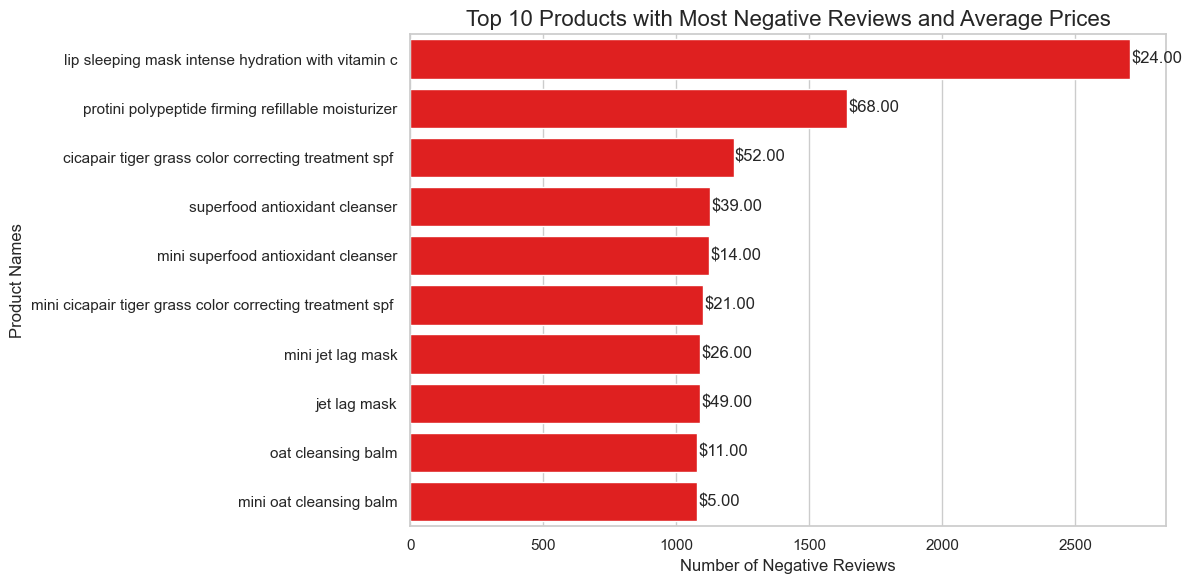

In [55]:
# Add a column for total reviews
product_sentiment_counts['total_reviews'] = product_sentiment_counts.sum(axis=1)

# Get top-10 products with the most positive reviews
top_positive_products = product_sentiment_counts.sort_values(by=1, ascending=False).head(10)
top_positive_prices = df[df['cleaned_product_name'].isin(top_positive_products.index)].groupby('cleaned_product_name')['price_usd'].mean()

# Get top-10 products with the most negative reviews
top_negative_products = product_sentiment_counts.sort_values(by=0, ascending=False).head(10)
top_negative_prices = df[df['cleaned_product_name'].isin(top_negative_products.index)].groupby('cleaned_product_name')['price_usd'].mean()

# Plot top-10 positive products
plt.figure(figsize=(12, 6))
sns.barplot(
    x=top_positive_products[1],
    y=top_positive_products.index,
    color="green"  
)
plt.title("Top 10 Products with Most Positive Reviews and Average Prices", fontsize=16)
plt.xlabel("Number of Positive Reviews", fontsize=12)
plt.ylabel("Product Names", fontsize=12)

# Annotate prices on the bars
for i, product in enumerate(top_positive_products.index):
    plt.text(top_positive_products[1].iloc[i] + 5, i, f"${top_positive_prices[product]:.2f}", va='center')

plt.tight_layout()
plt.show()

# Plot top-10 negative products
plt.figure(figsize=(12, 6))
sns.barplot(
    x=top_negative_products[0],
    y=top_negative_products.index,
    color="red"  
)
plt.title("Top 10 Products with Most Negative Reviews and Average Prices", fontsize=16)
plt.xlabel("Number of Negative Reviews", fontsize=12)
plt.ylabel("Product Names", fontsize=12)

# Annotate prices on the bars
for i, product in enumerate(top_negative_products.index):
    plt.text(top_negative_products[0].iloc[i] + 5, i, f"${top_negative_prices[product]:.2f}", va='center')

plt.tight_layout()
plt.show()

From the analysis, the **Lip Sleeping Mask Intense Hydration with Vitamin C** appears at the top for both **most positive** and **most negative** reviews. This suggests that while the product is widely used and liked, it also has a share of dissatisfied users. Other products like the **Protini Polypeptide Firming Refillable Moisturizer** and **Superfood Antioxidant Cleanser** also feature in both lists, indicating mixed reactions from customers.

- Products with **high positive reviews** tend to be well-known skincare essentials such as masks, serums, and cleansers.
- Some **highly priced products** (e.g., **Alpha Beta Extra Strength Daily Peel Pads - $92**) receive a significant amount of positive feedback, suggesting that users perceive them as worth the investment.
- On the **negative side**, some of the same products that have high positive reviews (e.g., **Lip Sleeping Mask, Protini Moisturizer**) also have a notable number of negative reviews, which might be due to variations in individual skin reactions.
- **More affordable products** (e.g., **Mini Oat Cleansing Balm - $5**) also appear in negative reviews, potentially due to performance concerns or high expectations from budget-friendly options.

This insight is valuable for Sephora, as it helps identify which products are polarizing in user sentiment. Brand can use this information to improve product supply or adjust marketing strategies.


## Examining whether **brand pricing** influences customer satisfaction.

**Sentiment Distribution by Brand Pricing**

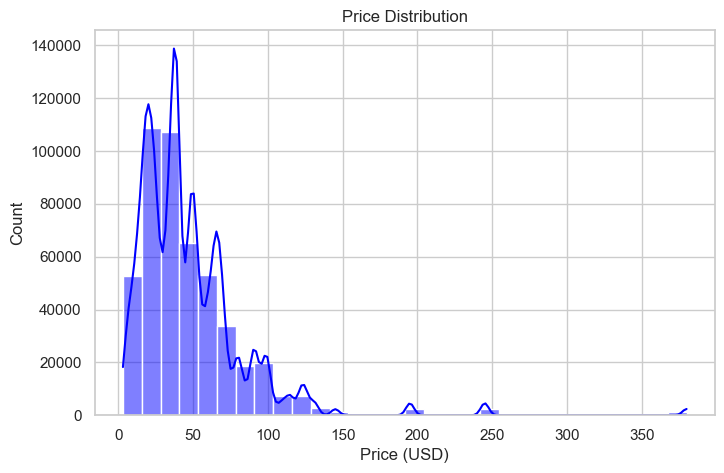

count    483645.000000
mean         47.145617
std          36.823536
min           3.000000
25%          24.000000
50%          39.000000
75%          62.000000
max         380.000000
Name: price_usd, dtype: float64


In [11]:
# Price Distribution
plt.figure(figsize=(8, 5))
sns.histplot(df['price_usd'], kde=True, bins=30, color='blue')
plt.title('Price Distribution')
plt.xlabel('Price (USD)')
plt.ylabel('Count')
plt.show()

print(df['price_usd'].describe())

The **price distribution of products** in Sephora shows a **right-skewed pattern**, indicating that the majority of products are **priced under $100**, with a significant concentration **between $10 and $50**. 

- The **highest frequency of products** falls within the **$20-$50 price range**, suggesting that most items in Sephora's catalog are **mid-range beauty products**.
- A **few luxury products** extend beyond **$150-$300**, but these are rare exceptions rather than the norm.
- The **smooth KDE curve overlay** further emphasizes the presence of **multiple price peaks**, potentially reflecting different pricing categories such as **drugstore, mid-range, and luxury** products.

This distribution indicates that Sephora offers **a wide range of products across various price points**, catering to both **budget-conscious and luxury-focused consumers**.

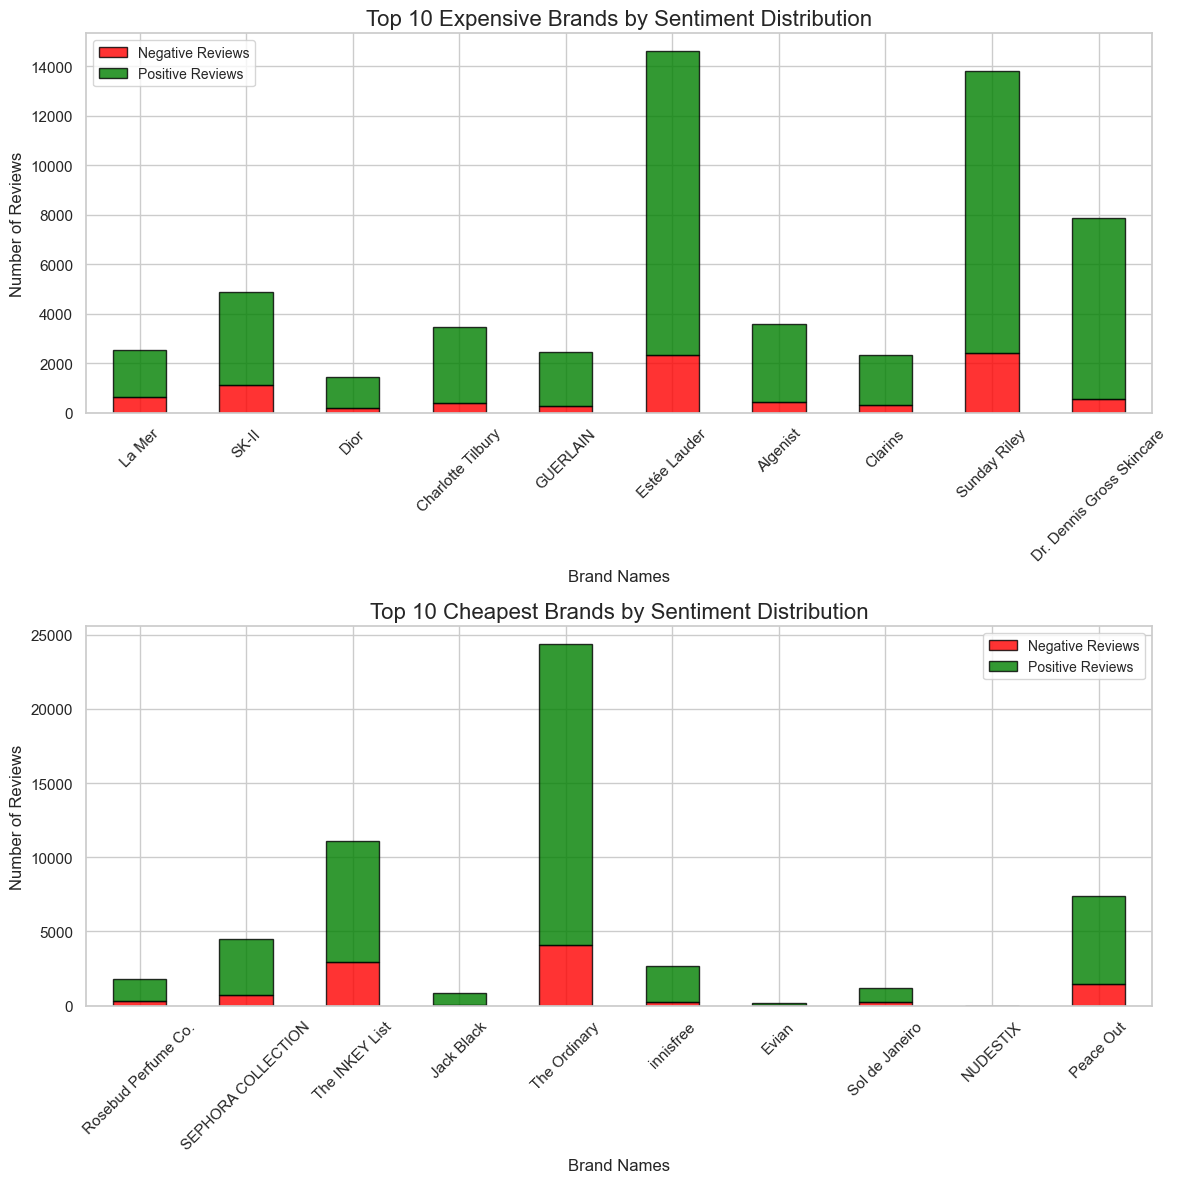

In [49]:
# Calculate average price for each brand
brand_avg_price = df.groupby('brand_name')['price_usd'].mean()

# Get the top-10 brands with the highest average prices
top_expensive_brands = brand_avg_price.sort_values(ascending=False).head(10)
top_expensive_brands_data = brand_sentiment_counts.loc[top_expensive_brands.index]

# Get the top-10 brands with the lowest average prices
top_cheap_brands = brand_avg_price.sort_values(ascending=True).head(10)
top_cheap_brands_data = brand_sentiment_counts.loc[top_cheap_brands.index]

# Create subplots for both graphs
fig, axes = plt.subplots(2, 1, figsize=(12, 12), sharex=False)

# Plot for top 10 expensive brands
top_expensive_brands_data.plot(
    kind='bar',
    stacked=True,
    color=['red', 'green'],
    alpha=0.8,
    edgecolor='black',
    ax=axes[0]
)
axes[0].set_title("Top 10 Expensive Brands by Sentiment Distribution", fontsize=16)
axes[0].set_xlabel("Brand Names", fontsize=12)
axes[0].set_ylabel("Number of Reviews", fontsize=12)
axes[0].legend(["Negative Reviews", "Positive Reviews"], fontsize=10)
axes[0].tick_params(axis='x', rotation=45)

# Plot for top 10 cheap brands
top_cheap_brands_data.plot(
    kind='bar',
    stacked=True,
    color=['red', 'green'],
    alpha=0.8,
    edgecolor='black',
    ax=axes[1]
)
axes[1].set_title("Top 10 Cheapest Brands by Sentiment Distribution", fontsize=16)
axes[1].set_xlabel("Brand Names", fontsize=12)
axes[1].set_ylabel("Number of Reviews", fontsize=12)
axes[1].legend(["Negative Reviews", "Positive Reviews"], fontsize=10)
axes[1].tick_params(axis='x', rotation=45)

# Adjust layout and display the plots
plt.tight_layout()
plt.show()

The analysis of **price distribution and sentiment analysis** across brands suggests that **higher-priced brands do not necessarily guarantee a higher proportion of positive reviews**. 

- While **some premium brands** such as *Estée Lauder* and *Charlotte Tilbury* received a significant number of positive reviews, **they also had a notable amount of negative feedback**.
- Conversely, **some affordable brands like The Ordinary and The INKEY List** also received **high positive sentiment**, indicating that **affordability does not equate to lower customer satisfaction**.

- **Expensive brands** tend to have **polarizing reviews**, with both **strong positive and negative sentiments**.
- **Cheaper brands** like *The Ordinary* gained a significant number of **positive reviews**, possibly due to their affordability and perceived value.

**Verification of Hypothesis**: The hypothesis that "more expensive brands are associated with a higher proportion of positive reviews" is **partially supported**, but **not universally true**. Brand perception and customer expectations play a **crucial role** in shaping sentiment, beyond just pricing.

## Analyzing the relationship between **review length and sentiment**.

**Text analysis: Length of texts for positive and negative reviews**

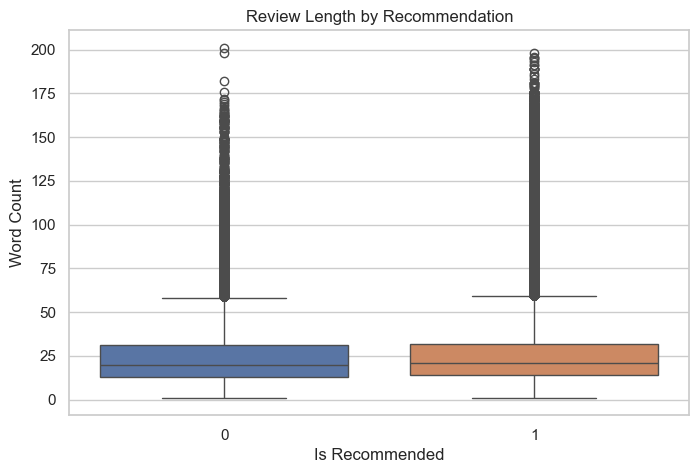

Average word count:
is_recommended
0    24.690979
1    25.818047
Name: review_word_count, dtype: float64


In [57]:
# Adding the column of Review_word_count
df['review_word_count'] = df['cleaned_review_text'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(8, 5))
sns.boxplot(x='is_recommended', y='review_word_count', data=df, hue='is_recommended', dodge=False, legend=False)
plt.title('Review Length by Recommendation')
plt.xlabel('Is Recommended')
plt.ylabel('Word Count')
plt.show()

# Average the length of text
mean_lengths = df.groupby('is_recommended')['review_word_count'].mean()
print("Average word count:")
print(mean_lengths)

The boxplot visualization compares the **word count** of reviews based on their sentiment (**recommended vs. not recommended**). 

**Verification of Hypothesis**: The analysis does not provide strong evidence to support the hypothesis that **negative reviews tend to be longer** on average than positive reviews.

- The **median review length** appears to be **similar** for both positive and negative reviews.
- There is a **wide range of review lengths** in both categories, with **many outliers** extending beyond 100 words.
- Some **positive reviews exhibit extreme lengths**, suggesting that satisfied customers might provide more detailed feedback, but overall, the distributions are quite comparable.

Thus, while some **long negative or positive reviews exist**, the **overall trend does not show a substantial difference** in review length between positive and negative feedback.


**Frequent words in positive and negative reviews**

In [18]:
def calculate_word_proportions(pos_reviews, neg_reviews):
    pos_counts = Counter(pos_reviews.split())
    neg_counts = Counter(neg_reviews.split())
    total_pos = sum(pos_counts.values())
    total_neg = sum(neg_counts.values())

    word_ratios = {}
    for word in set(pos_counts.keys()).union(set(neg_counts.keys())):
        pos_ratio = pos_counts[word] / total_pos if word in pos_counts else 0
        neg_ratio = neg_counts[word] / total_neg if word in neg_counts else 0
        word_ratios[word] = {'positive_ratio': pos_ratio, 'negative_ratio': neg_ratio}

    return word_ratios

word_ratios = calculate_word_proportions(positive_reviews, negative_reviews)

word_ratios_df = pd.DataFrame.from_dict(word_ratios, orient='index')
word_ratios_df['ratio_difference'] = word_ratios_df['positive_ratio'] - word_ratios_df['negative_ratio']
word_ratios_df = word_ratios_df.sort_values(by='ratio_difference', ascending=False)

# Top-10 words associated with positive and negative reviews
print("Top 10 words associated with positive reviews:")
print(word_ratios_df.head(10))

print("\nTop 10 words associated with negative reviews:")
print(word_ratios_df.tail(10))


Top 10 words associated with positive reviews:
            positive_ratio  negative_ratio  ratio_difference
love              0.018721        0.008172          0.010549
skin              0.047241        0.040318          0.006922
soft              0.005665        0.001343          0.004322
amazing           0.005515        0.001227          0.004288
smooth            0.005360        0.001254          0.004106
use               0.014327        0.010434          0.003893
great             0.007861        0.004428          0.003432
definitely        0.005857        0.002810          0.003047
recommend         0.006046        0.003626          0.002420
night             0.004965        0.002661          0.002303

Top 10 words associated with negative reviews:
               positive_ratio  negative_ratio  ratio_difference
try                  0.008082        0.010223         -0.002142
unfortunately        0.000188        0.002345         -0.002156
return               0.000173        0.002

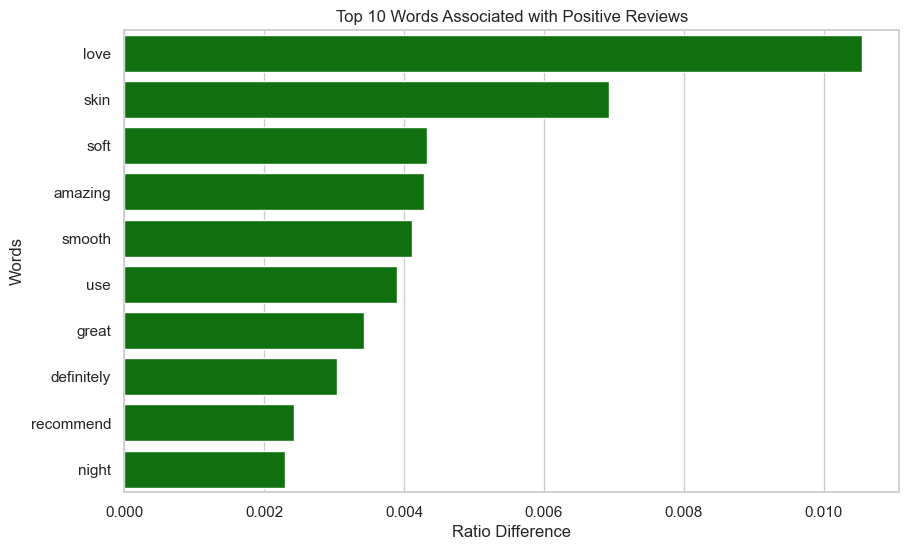

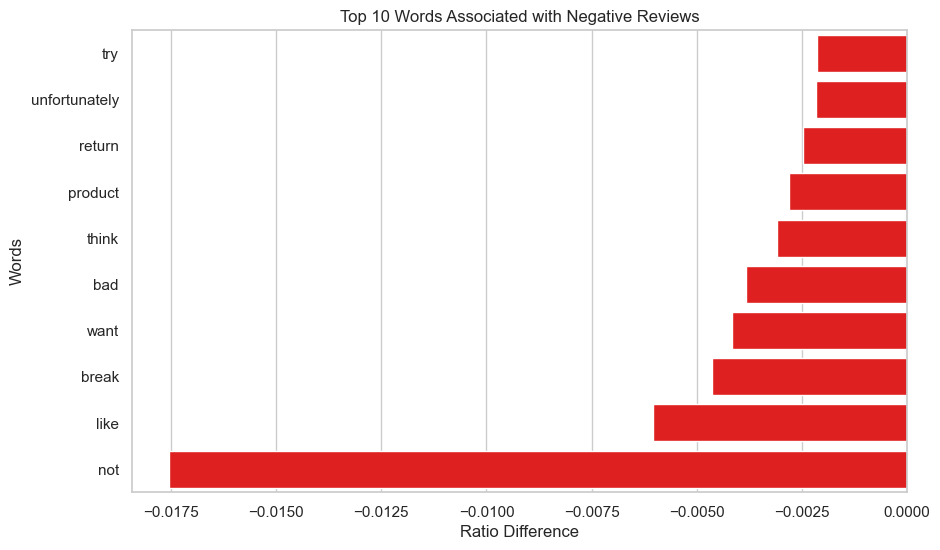

In [25]:
# Preparing the data for visualization
top_positive_words = word_ratios_df.head(10).reset_index()
top_negative_words = word_ratios_df.tail(10).reset_index()

def plot_top_words(data, title, column='ratio_difference', color='green'):
    plt.figure(figsize=(10, 6))
    sns.barplot(
        x=column,
        y='index',
        data=data,
        color=color  
    )
    plt.title(title)
    plt.xlabel('Ratio Difference')
    plt.ylabel('Words')
    plt.show()

plot_top_words(top_positive_words, "Top 10 Words Associated with Positive Reviews", color='green')

plot_top_words(top_negative_words, "Top 10 Words Associated with Negative Reviews", color='red')

The analysis of word frequency in positive and negative reviews provides key insights into the language used by customers when expressing satisfaction or dissatisfaction.

- **Positive reviews** are strongly associated with words like *love, skin, soft, amazing, smooth, use, great, definitely, recommend, night*. These words indicate a preference for product texture (*soft, smooth*), effectiveness (*amazing, great*), and a general endorsement (*love, recommend*). The frequent appearance of *night* suggests that many of these products are used in nighttime skincare routines.

- **Negative reviews** contain words such as *not, like, break, want, bad, think, product, return, unfortunately, try*. The presence of *not* and *bad* suggests direct dissatisfaction, while words like *break, return*, and *unfortunately* indicate issues with product performance or customer dissatisfaction leading to product returns. Interestingly, *think* appears frequently, suggesting that negative reviewers may be more reflective or hesitant in their feedback compared to those writing positive reviews.

Overall, positive reviews tend to focus on product quality, effectiveness, and recommendation, whereas negative reviews emphasize disappointment, product failures, and the need for returns.


## Identifying **trends** in **positive and negative reviews** over time.

**Time-Based Analysis of Positive and Negative Reviews**

<Figure size 1200x600 with 0 Axes>

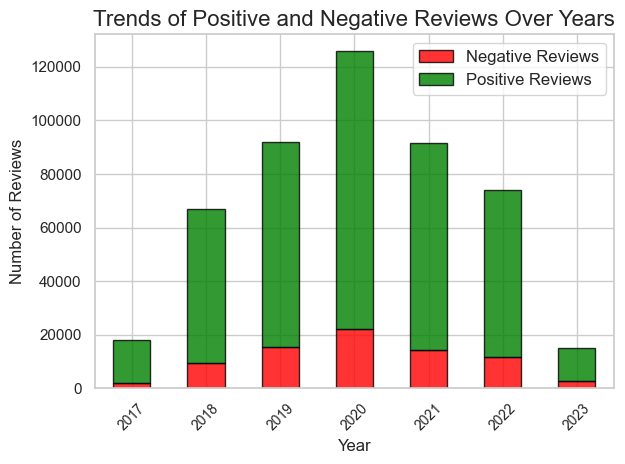

<Figure size 1200x600 with 0 Axes>

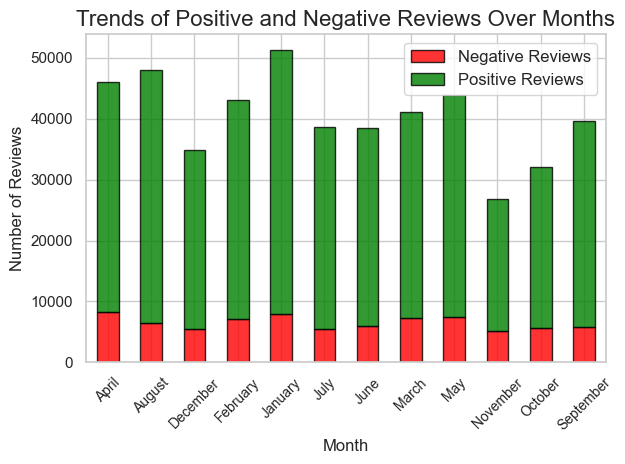

In [60]:
if 'year' in df.columns and 'month' in df.columns and 'is_recommended' in df.columns:
    
    # Trends for years
    yearly_trends = df.groupby(['year', 'is_recommended']).size().unstack(fill_value=0)

    # Trend graphs for years
    plt.figure(figsize=(12, 6))
    yearly_trends.plot(kind='bar', stacked=True, color=['red', 'green'], alpha=0.8, edgecolor='black')
    plt.title('Trends of Positive and Negative Reviews Over Years', fontsize=16)
    plt.xlabel('Year', fontsize=12)
    plt.ylabel('Number of Reviews', fontsize=12)
    plt.legend(["Negative Reviews", "Positive Reviews"], fontsize=12)
    plt.xticks(rotation=45, fontsize=10)
    plt.tight_layout()
    plt.show()

    # Trend graphs for months
    monthly_trends = df.groupby(['month', 'is_recommended']).size().unstack(fill_value=0)

    plt.figure(figsize=(12, 6))
    monthly_trends.plot(kind='bar', stacked=True, color=['red', 'green'], alpha=0.8, edgecolor='black')
    plt.title('Trends of Positive and Negative Reviews Over Months', fontsize=16)
    plt.xlabel('Month', fontsize=12)
    plt.ylabel('Number of Reviews', fontsize=12)
    plt.legend(["Negative Reviews", "Positive Reviews"], fontsize=12)
    plt.xticks(rotation=45, fontsize=10)
    plt.tight_layout()
    plt.show()

else:
    print("Error: Required columns ('year', 'month', 'is_recommended') are missing in the dataset.")

- The yearly trend analysis shows that **the number of reviews significantly increased from 2017 to 2020**, peaking in 2020. This could be attributed to the COVID-19 pandemic, where more customers engaged in online shopping and left reviews. After 2020, the number of reviews gradually declined, suggesting a stabilization in user engagement.

- The monthly trend analysis indicates that **certain months, such as January, August, and April, tend to have a higher number of reviews**, which could correspond to seasonal trends in beauty product purchases, such as post-holiday shopping or summer skincare routines.

- **Positive reviews consistently outweigh negative reviews across all years and months**, indicating that overall, customers tend to be more satisfied with their purchases.
- There is no specific month where negative reviews drastically increase, implying that customer dissatisfaction is relatively stable throughout the year.

These insights can be useful for **predicting demand trends** and identifying the best time for promotions, product launches, or customer engagement strategies.


## Exploring Key Themes in Customer Reviews Using **LDA Topic Modeling**

In [13]:
df = df.dropna(subset=['cleaned_review_text'])
corpus = df['cleaned_review_text'].astype(str)  # Convert to string

# Convert text into a word frequency matrix
vectorizer = CountVectorizer(max_features=5000, stop_words='english')
X = vectorizer.fit_transform(corpus)

# Train LDA Model
lda = LatentDirichletAllocation(n_components=5, random_state=42)  # 5 topics
lda.fit(X)

# Display the most important words per topic
def print_top_words(model, feature_names, n_top_words=10):
    for topic_idx, topic in enumerate(model.components_):
        print(f"Topic #{topic_idx + 1}:")
        print(" ".join([feature_names[i] for i in topic.argsort()[:-n_top_words - 1:-1]]))

print_top_words(lda, vectorizer.get_feature_names_out(), n_top_words=10)

Topic #1:
makeup skin cleanser face feel like product clean use love
Topic #2:
product skin eye cream serum like notice use feel line
Topic #3:
skin product use acne face try ve work week love
Topic #4:
skin feel product love receive smell soft leave face smooth
Topic #5:
skin lip dry moisturizer like love product feel use day


LDA topic modeling was applied to identify the most prominent themes in customer reviews. The analysis revealed **five key topics**, each representing different aspects of customer experiences and product features.

### **Topics Identified:**
1. **Makeup and Cleansers** – Customers frequently discuss **cleansers, makeup products, and their effectiveness** in cleaning the skin.
2. **Skincare and Eye Care** – Many reviews focus on **skincare routines, eye creams, and serums**, with attention to how they feel and whether they show noticeable results.
3. **Acne Treatment and Effectiveness Over Time** – Users talk about **products designed for acne treatment**, their effectiveness, and experiences after continuous use.
4. **Texture, Scent, and Absorption** – A significant portion of reviews mentions **how products feel on the skin, their scent, and whether they absorb well**.
5. **Moisturization and Hydration** – Many customers discuss **moisturizers, lip care, and hydration**, emphasizing how well products **keep skin smooth and soft**.


# **6.  Modeling and Evaluation**  

The **modeling and evaluation** process was conducted in the **`notebooks/modeling.ipynb`** file. This step includes:  

- **Data Preparation for Modeling**:  
  - Splitting data into **training** and **testing** sets.  
  - Addressing **class imbalance** using **SMOTE**.  
  - **TF-IDF vectorization** for text transformation.  

- **Model Training**:  
  - Implemented **Logistic Regression, Naive Bayes, Random Forest, and Gradient Boosting** classifiers.  
  - Each model was trained on the balanced dataset and **evaluated** based on key performance metrics.  
  - The **`src/models.py`** file contains modular functions for vectorization, training, and evaluation, making the modeling pipeline **efficient and reusable**.  

- **Model Evaluation**:  
  - Used **Accuracy, Precision, Recall, and F1-Score** to assess performance.  
  - Visualized **Confusion Matrices** and **ROC Curves** for comparison.  

📄 **You can find the full implementation in:**  
📂 **[`notebooks/modeling.ipynb`](./notebooks/modeling.ipynb)** 🚀  
📂 **[`src/models.py`](./src/models.py)** 🔧 (Contains core model functions)



### **Conclusion from the **`notebooks/modeling.ipynb`** file**

#### **1. Model Performance Comparison**
We tested four different machine learning models:
- **Logistic Regression**: Achieved **90% accuracy** with high precision and recall, making it a strong and well-balanced classifier.
- **Naive Bayes**: Performed well (**86% accuracy**), especially in handling imbalanced data, but struggled slightly with false positives.
- **Random Forest**: Had the **highest accuracy (93%)** and strong recall, making it a robust choice but computationally expensive.
- **Gradient Boosting**: Showed moderate performance (**81% accuracy**) but was less effective compared to the other models.

#### **2. Key Observations**
- **ROC Curves & AUC Scores**: Random Forest and Logistic Regression had the highest AUC values (**0.94+**), indicating strong classification capabilities.
- **Confusion Matrices**: All models struggled slightly with classifying negative reviews, possibly due to class imbalance.

#### **3. Feature Importance: Key Words in Sentiment Analysis**
We extracted the most influential words associated with **positive and negative** reviews. 

#### **Top words in positive reviews:**
Words like **"love," "amazing," "smooth," "soft," "highly recommend"** were frequently associated with positive sentiment. These words suggest that customers highly value **quality, effectiveness, and pleasant experience** in skincare products.

#### **Top words in negative reviews:**
Negative reviews often contained words like **"return," "disappointing," "unfortunately," "meh," "want love," "save money"**—indicating issues related to **product dissatisfaction, unmet expectations, and regrets about purchases**.

- **Best Performing Model**: Logistic Regression and Random Forest demonstrated the best balance between performance and efficiency.

Overall, this modeling approach provided valuable insights into customer sentiment and product reception. 


# **7. Summary of Project**

## **Was the purpose achieved?**
The primary goal of this project was to analyze customer reviews for skincare and beauty products to determine **sentiment trends, key themes, and factors influencing customer satisfaction**. By applying **text mining, sentiment analysis, and topic modeling**, we successfully extracted valuable insights about customer preferences, frequently discussed topics, and sentiment distribution across brands and products. 

## **Were the assumptions examined?**
Throughout the analysis, we tested the following assumptions:
- **Expensive brands receive more positive reviews** – While higher-end brands generally had a greater number of positive reviews, **price alone was not a direct determinant of customer satisfaction**.
- **Negative reviews tend to be longer** – Our analysis showed **only a slight difference** in review lengths between positive and negative reviews, disproving a significant correlation.

## **Conclusions from Obtained Results**
1. **Sentiment Distribution** – The majority of reviews were **positive**, indicating overall customer satisfaction with skincare and beauty products.
2. **Top Brands and Products** – Brands like **Tatcha, Drunk Elephant, and The Ordinary** received the highest number of positive reviews, while some of the same brands also appeared in negative review rankings, highlighting **polarizing customer experiences**.
3. **Price Influence on Reviews** – While **premium brands had more positive reviews**, affordability was also a key factor for positive sentiment in brands like **The Ordinary and The Inkey List**.
4. **Most Discussed Themes in Reviews** – LDA Topic Modeling identified **skincare concerns, hydration, texture, and acne treatment** as dominant themes across reviews.
5. **Importance of Word Frequency in Sentiment Analysis** – The most important words for sentiment classification, such as **"love" for positive reviews and "disappointed" for negative reviews**, provided deeper insight into what influences customer opinions.
6. **Performance of Sentiment Classification Models** – Among all tested models, **Logistic Regression and Random Forest performed the best** in predicting review sentiment with high precision and recall.

This study demonstrated that **text mining and sentiment analysis are powerful tools for understanding customer preferences** in the beauty industry. By leveraging **machine learning, NLP techniques, and topic modeling**, companies can gain actionable insights to **improve product offerings, enhance customer experience and drive better marketing strategies**.


# **Appendix**

## **Source Code**
The complete source code for data preprocessing, modeling, and visualization is organized within the project's directory. Below are the key files:

- 📂 **`src/`** (Source code folder)
  - **[`data_cleaning.py`](../src/data_cleaning.py)** – Contains functions for text preprocessing, including stopword removal, lemmatization, and cleaning reviews and product names.
  - **[`models.py`](../src/models.py)** – Implements machine learning models (Logistic Regression, Naïve Bayes, Random Forest, Gradient Boosting) for sentiment classification.
  
- 📂 **`notebooks/`** (Jupyter notebooks)
  - **[`main.ipynb`](../notebooks/main.ipynb)** – The primary notebook summarizing all steps, including data analysis, modeling, and results interpretation.
  - **[`modeling.ipynb`](../notebooks/modeling.ipynb)** – Detailed training, evaluation, and performance comparison of sentiment classification models.

## **Dataset**
The dataset used for this analysis is sourced from Kaggle:  
[Sephora Products and Skincare Reviews](https://www.kaggle.com/datasets/nadyinky/sephora-products-and-skincare-reviews?select=product_info.csv).

- 📂 **`data/`**
  - **[`reviews_0-250.csv`](../data/reviews_0-250.csv)** – The raw dataset containing customer reviews, ratings, and product details.
  - **[`cleaned_reviews.csv`](../data/cleaned_reviews.csv)** – The preprocessed dataset, cleaned and prepared for analysing and modeling.
